In [1]:
import numpy as np
from matplotlib import pyplot as plt

from mw_toolkit import *

# Setup Option 1 - Mode 1 - Analog Frequency Source

This setup uses a 0-3Ghz Analogue Frequency Source for tuning between hyper-fine states of Rb (SMBB-B103)

Mode 1 means that the SMBB-B103 generates a signal between 1.5 and 2GHz

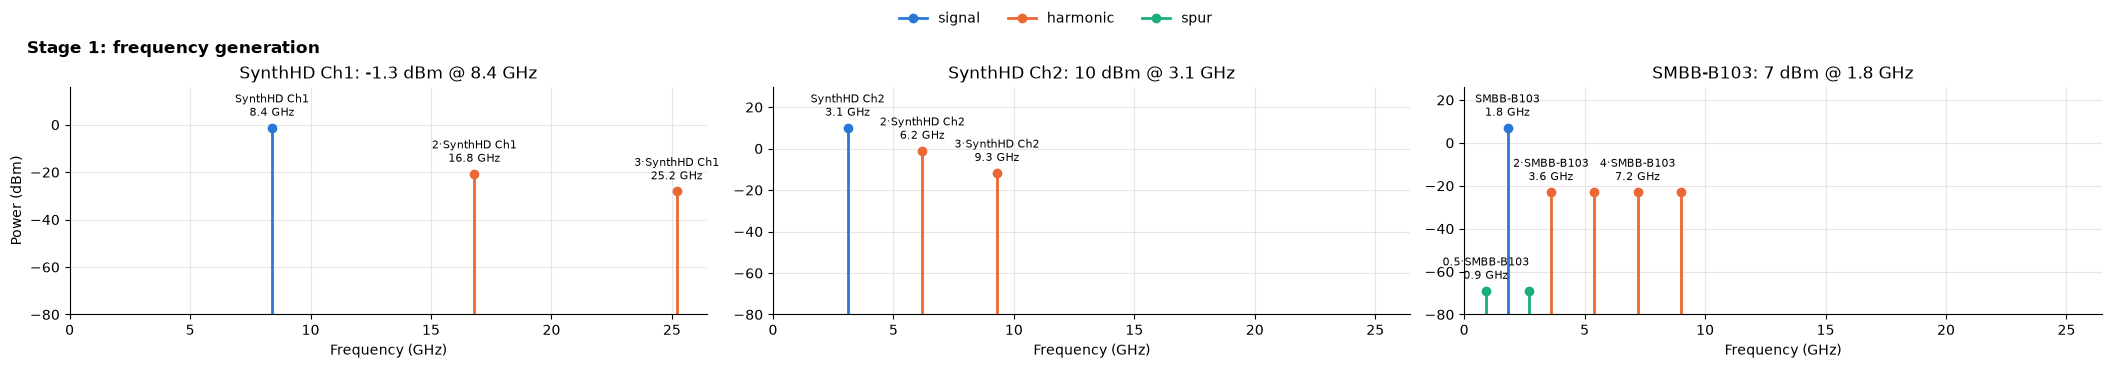

In [3]:
# Stage 1
# - frequency generation of a 8.4 GHz signal (Windfreak Synth HD V2 - Channel 1)
lo = pll_synthesizer(P_dBm = -1.3, f_GHz = 8.4, preset='SynthHD v2', name='SynthHD Ch1')

# - frequency generation of a 3.1 GHz signal (Windfreak Synth HD V2 - Channel 2)
mw_1 = pll_synthesizer(P_dBm = 10, f_GHz = 3.1, preset='SynthHD v2', name='SynthHD Ch2')

# - frequency generation of a 1.5 - 2 GHz signal (SMBB-B103)
mw_2 = analog_source(P_dBm = 7, f_GHz = 1.8, harmonic_dBc = -30, n_harmonics=5, 
                     nonharmonic_dBc=-76, subharmonics = [(0.5, -76),(1.5, -76)], name = 'SMBB-B103')

plot_stages = {'Stage 1: frequency generation': [lo, mw_1, mw_2]}

axes = plot_stage_rows(plot_stages, dBc=False, floor=-80)

axes[0][2].get_figure(root=True).savefig("test.png")

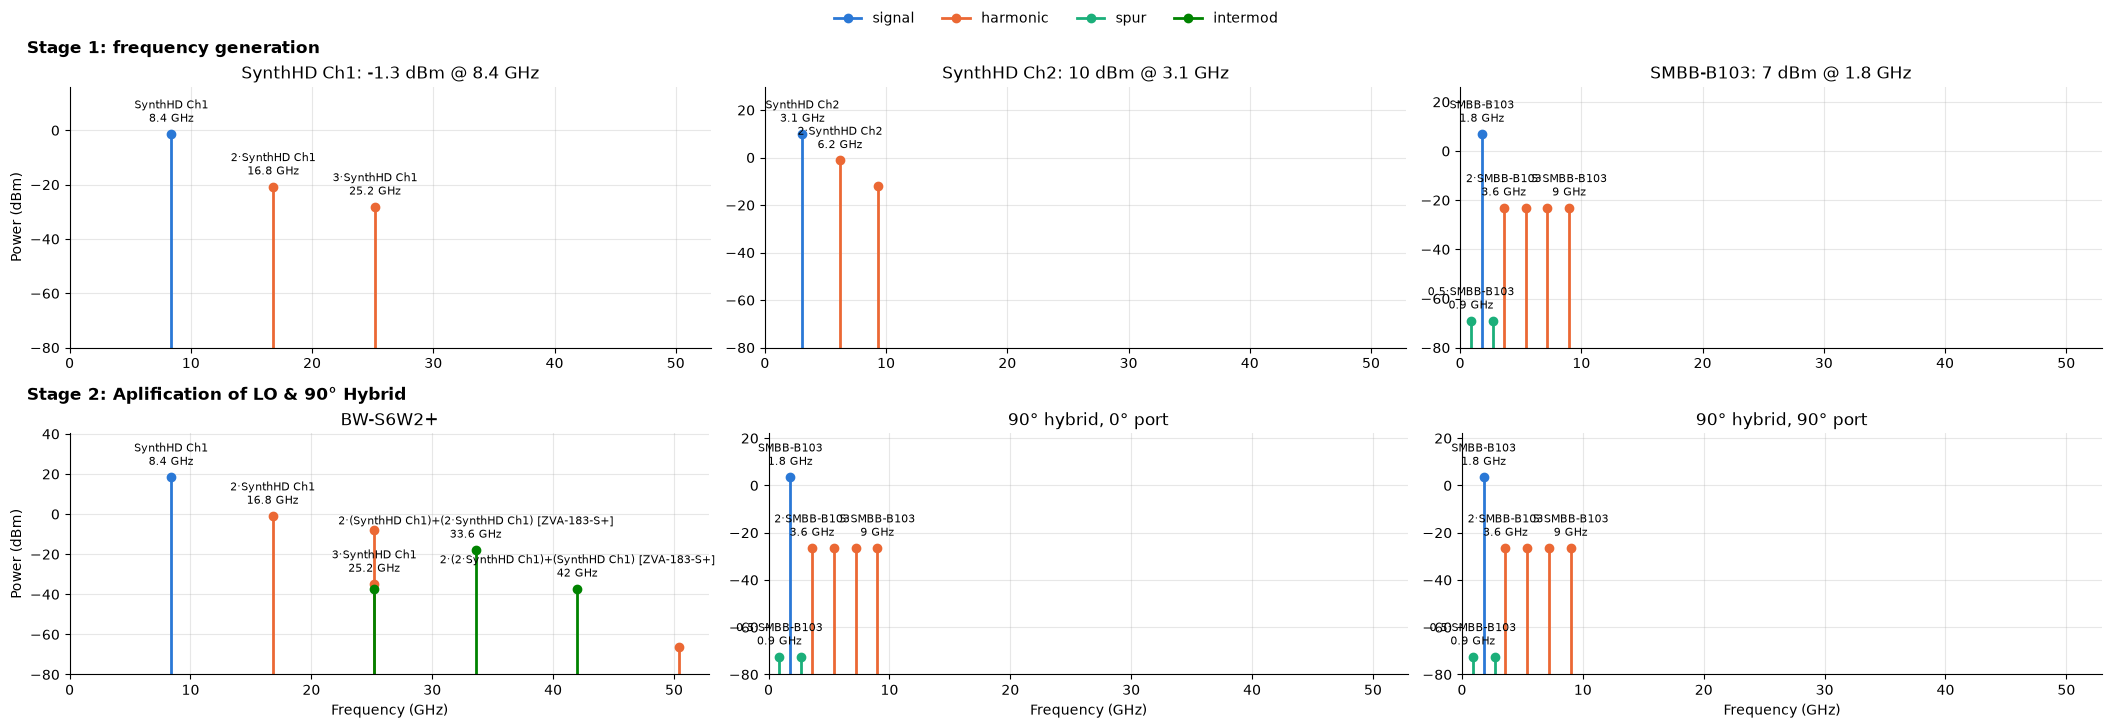

In [4]:
# Stage 2 ampllification of SynthHD 8.4 Ghz LO + Attenuator and 90° Hybrids
# Amp of LO
lo = amplifier(lo, gain_dB= lambda f : 26.5 if f < 18 else 0, p1db_dBm=25.3, oip3_dBm=33, label='ZVA-183-S+')
lo = attenuator(lo, 6, label='BW-S6W2+')

# 90° Hybrif for mw_2 - ZX10Q-2-25-S+
mw_2_i, mw_2_q = hybrid_90(mw_2, insertion_loss_dB=0.4)

plot_stages["Stage 2: Aplification of LO & 90° Hybrid"] = [lo, mw_2_i, mw_2_q]

axes = plot_stage_rows(plot_stages, dBc=False, floor=-80)
axes[0][2].get_figure(root=True).savefig("test.png")

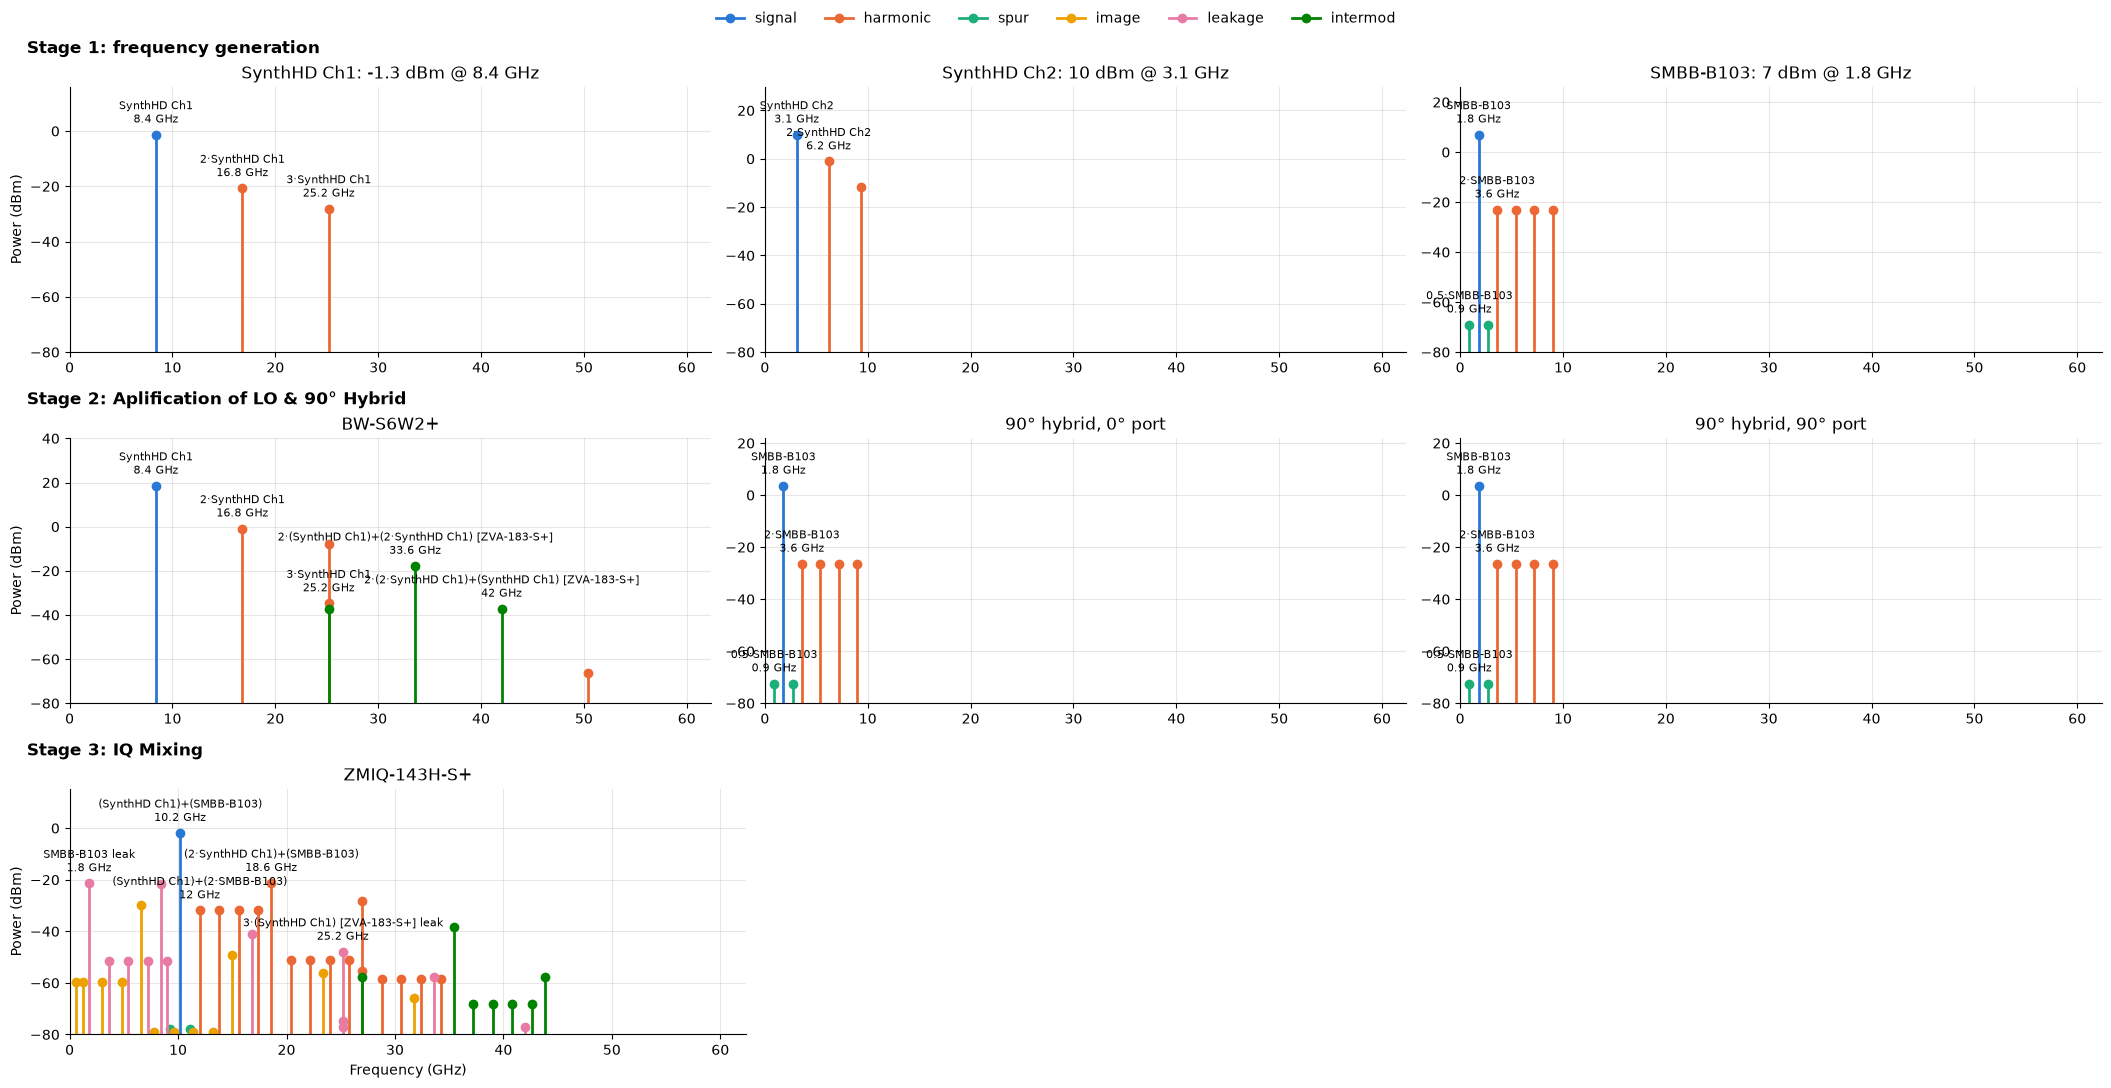

In [5]:
# Stage 3 - IQ Mixing
# IQ mixer of LO with mw_2_i and mw_2_q
mw_3 = iq_mixer(lo, mw_2_i, conv_loss_dB=8.5, sideband='upper',
                amp_imbalance_dB=0.2, phase_imbalance_deg=4.5,   # or: sideband_suppression_dBc=-30
                lo_rf_isolation_dB=40, if_rf_isolation_dB=25,
                label='ZMIQ-143H-S+')

plot_stages["Stage 3: IQ Mixing"] = [mw_3]

axes = plot_stage_rows(plot_stages, dBc=False, floor=-80)
axes[0][2].get_figure(root=True).savefig("test.png")

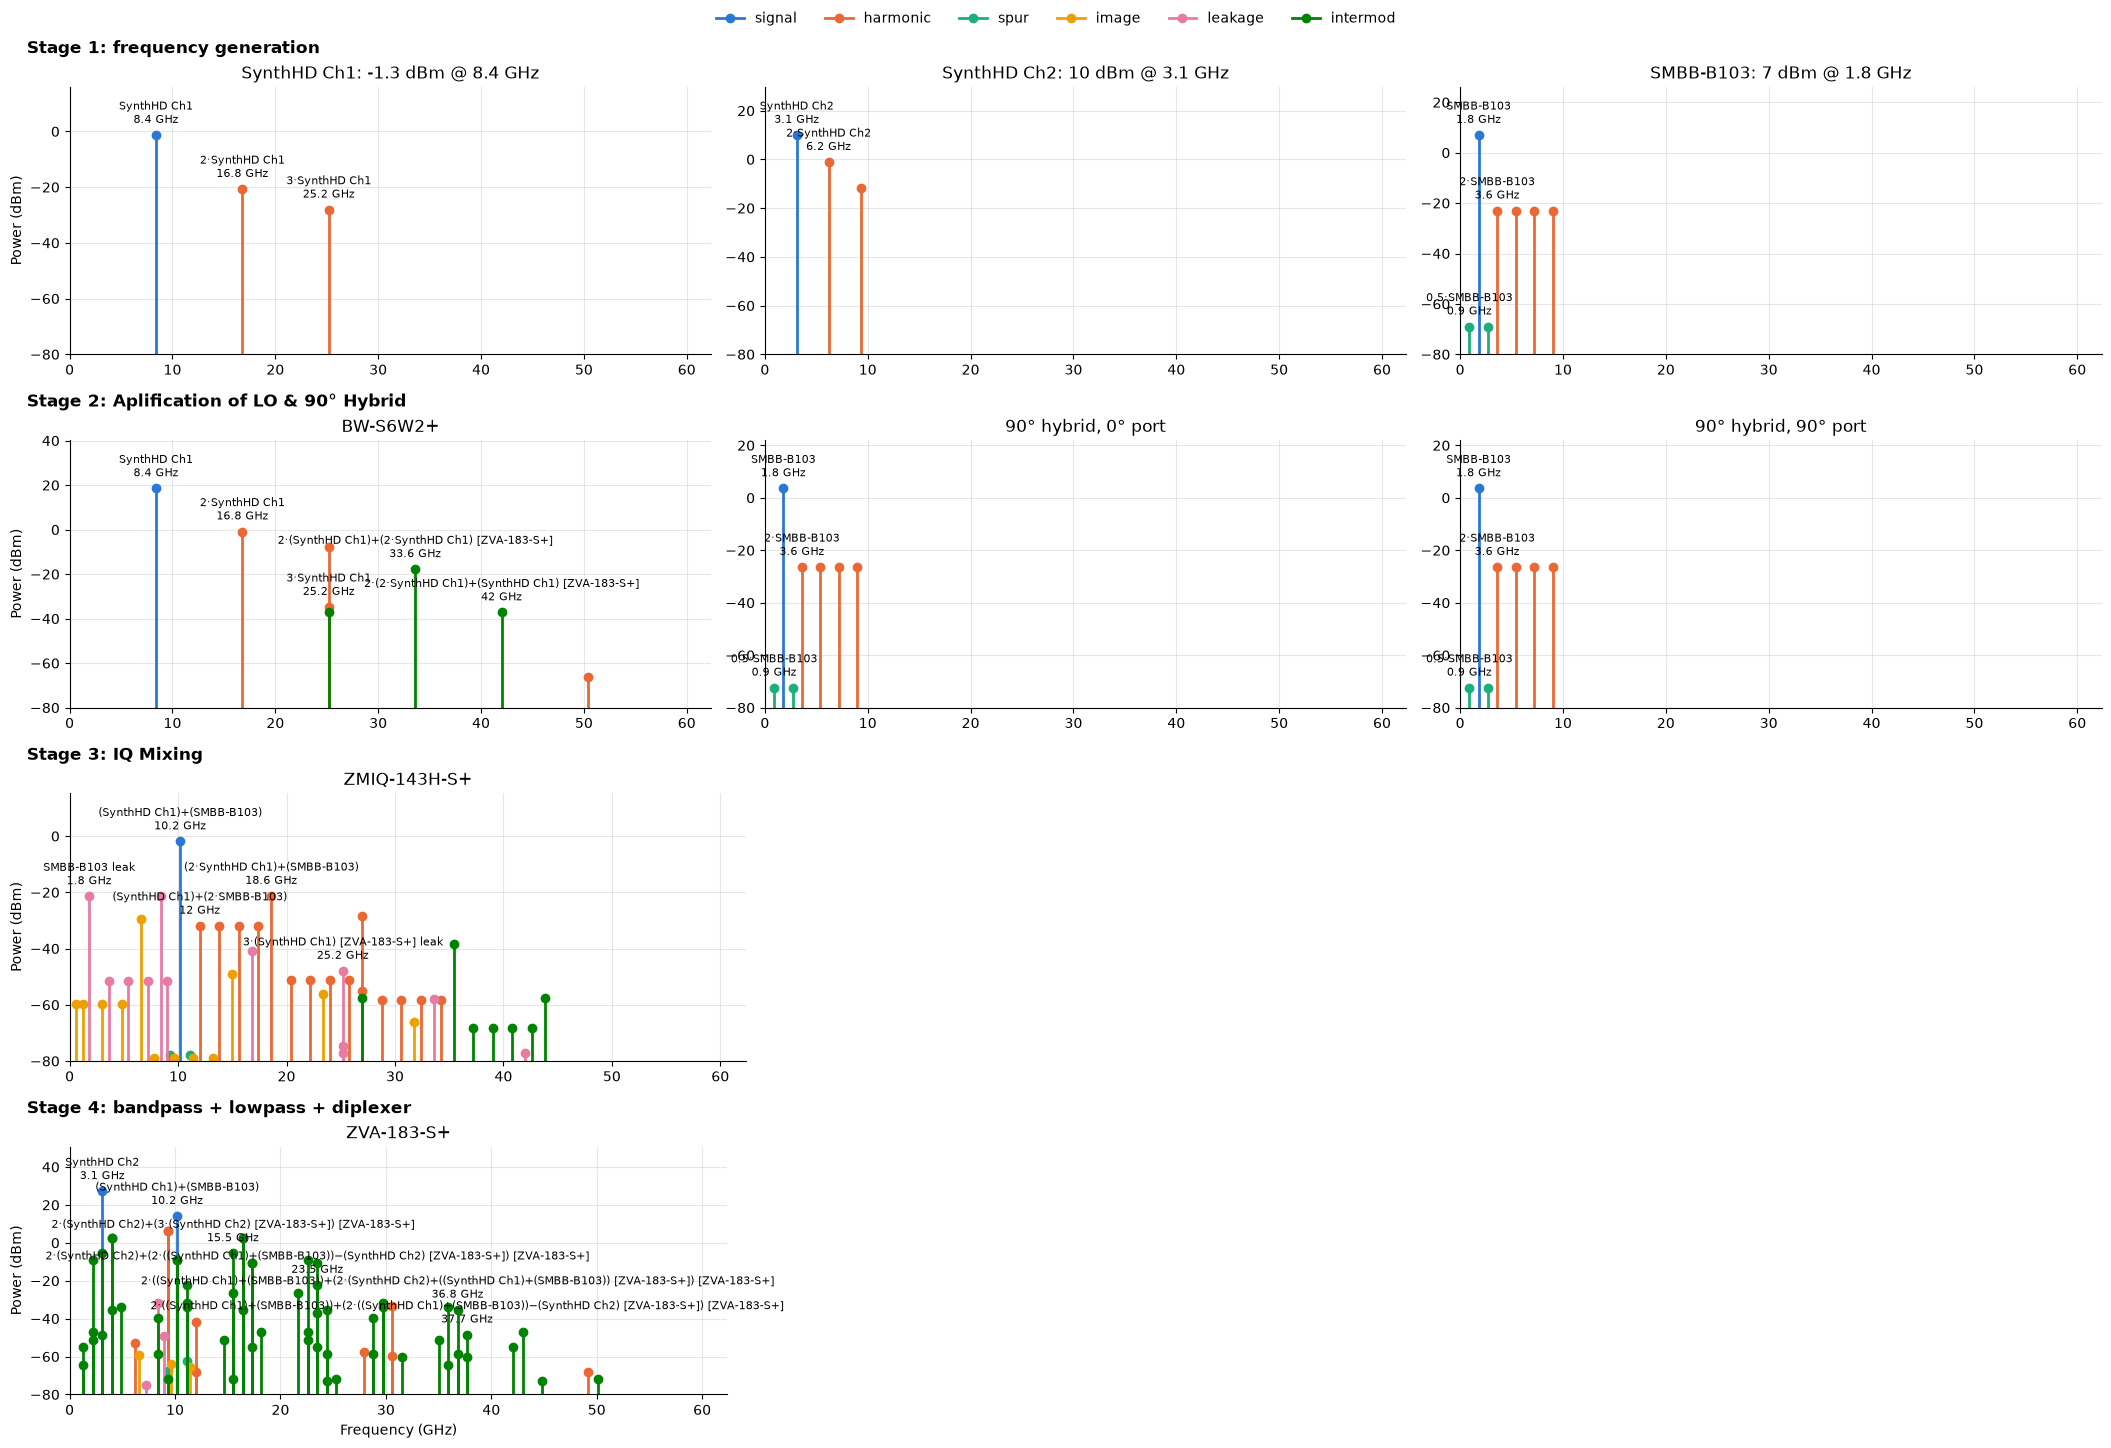

In [6]:
# Stage 4 - IQ Mixing Bandpass of the 9.9-10.4 Ghz signal

mw_3_bp = filter_from_table(mw_3, part='ZVBP-10R5G-S+')      # 9.75-11.25 GHz
mw_3_lp = filter_from_table(mw_3_bp, part='ZLSS-11G-S+')     # DC-11 GHz

# 3.1 GHz line: SynthHD ch2. Its spurs are harmonics (6.2, 9.3 GHz) -> lowpass.
# A highpass is not needed: the SynthHD puts nothing below 3.1 GHz (VCO at
# 6.2 GHz divided by 2, no subharmonic).

mw_1_lp = filter_from_table(mw_1, part='VLF-3800+')         # DC-3.9 GHz

# combiner: diplexer (low loss, filters each input once more).
# Alternative: power_combiner(ch2_lp, rf_lp) -> 3 dB + 0.5 dB loss on both lines.
out = diplexer_combine(mw_1_lp, mw_3_lp, part='ZDSS-5G6G-S+',
                       label='Output (ZDSS-5G6G-S+)')

out = amplifier(out, gain_dB= lambda f : 26.5 if f < 18 else 0, p1db_dBm=25.3, oip3_dBm=33, label='ZVA-183-S+')



out = amplifier(out, gain_dB= lambda f : 26.5 if f < 18 else 0, p1db_dBm=25.3, oip3_dBm=33, label='ZVA-183-S+')

plot_stages["Stage 4: bandpass + lowpass + diplexer"] = [out]

axes = plot_stage_rows(plot_stages, dBc=False, floor=-80)
axes[0][2].get_figure(root=True).savefig("Setup1_Mode1.png")

# Setup Option 1 - Mode 2 - Analog Frequency Source

This setup uses a 0-3Ghz Analogue Frequency Source for tuning between hyper-fine states of Rb (SMBB-B103)

Mode 1 means that the SMBB-B103 generates a signal between 2 and 2.5GHz

The Channel 1 SynthDH runs at 7.9 Ghz as LO

Tone(f_GHz=3.1, P_dBm=np.float64(10.395428571428573), origin='SynthHD Ch2', kind='signal', phase_deg=np.float64(0.0))
Tone(f_GHz=6.2, P_dBm=np.float64(-69.61000000000001), origin='2·SynthHD Ch2', kind='harmonic', phase_deg=np.float64(0.0))
Tone(f_GHz=9.3, P_dBm=np.float64(-136.18494680851063), origin='3·SynthHD Ch2', kind='harmonic', phase_deg=np.float64(0.0))
Tone(f_GHz=10.2, P_dBm=np.float64(21.81783415077584), origin='(SynthHD Ch1)+(SMBB-B103)', kind='signal', phase_deg=np.float64(0.0))
Tone(f_GHz=5.6000000000000005, P_dBm=np.float64(-64.22161912320452), origin='(SynthHD Ch1)−(SMBB-B103) image', kind='image', phase_deg=np.float64(0.0))
Tone(f_GHz=12.5, P_dBm=np.float64(-58.03103251589082), origin='(SynthHD Ch1)+(2·SMBB-B103)', kind='harmonic', phase_deg=np.float64(0.0))
Tone(f_GHz=3.3000000000000007, P_dBm=np.float64(-158.61271923952225), origin='(SynthHD Ch1)−(2·SMBB-B103) image', kind='image', phase_deg=np.float64(0.0))
Tone(f_GHz=14.8, P_dBm=np.float64(-126.93081146325926), origi

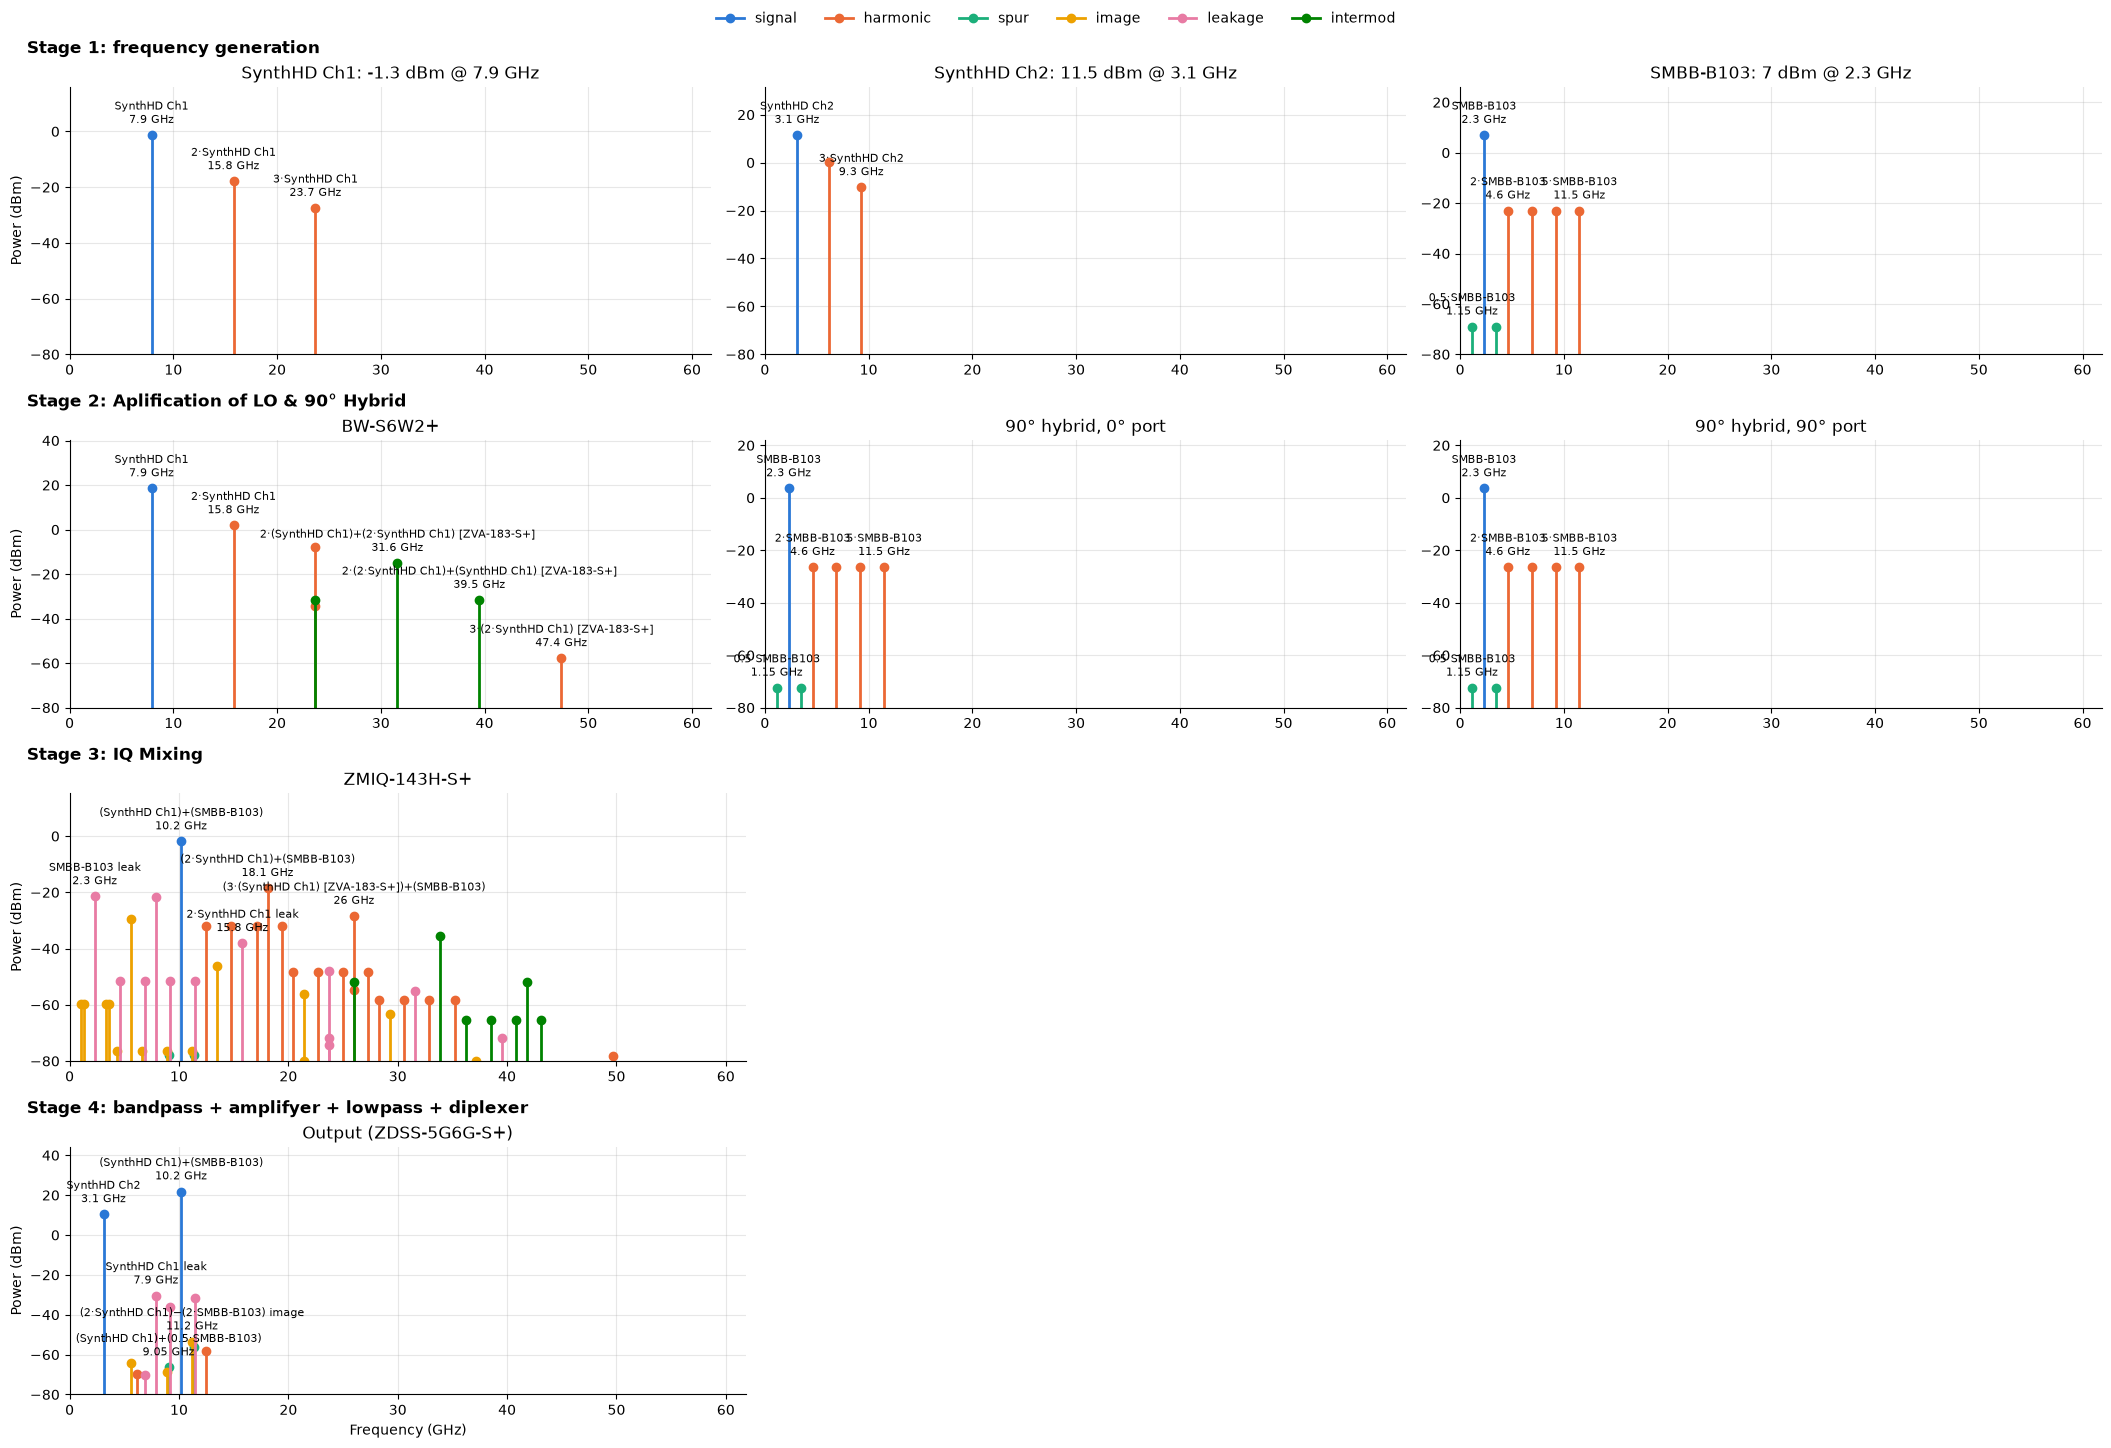

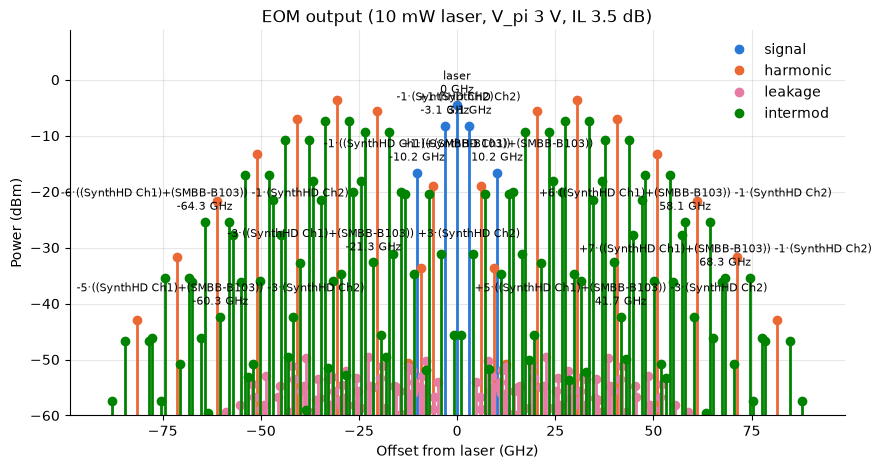

In [ ]:
# Stage 1
# - frequency generation of a 8.4 GHz signal (Windfreak Synth HD V2 - Channel 1)
lo = pll_synthesizer(P_dBm = -1.3, f_GHz = 7.9, preset='SynthHD v2', name='SynthHD Ch1')

# - frequency generation of a 3.1 GHz signal (Windfreak Synth HD V2 - Channel 2)
mw_1 = pll_synthesizer(P_dBm = 11.5, f_GHz = 3.1, preset='SynthHD v2', name='SynthHD Ch2')

# - frequency generation of a 1.5 - 2 GHz signal (SMBB-B103)
mw_2 = analog_source(P_dBm = 7, f_GHz = 2.3, harmonic_dBc = -30, n_harmonics=5, 
                     nonharmonic_dBc=-76, subharmonics = [(0.5, -76),(1.5, -76)], name = 'SMBB-B103')

plot_stages = {'Stage 1: frequency generation': [lo, mw_1, mw_2]}

# Stage 2 ampllification of SynthHD 8.4 Ghz LO + Attenuator and 90° Hybrids
# Amp of LO
lo = amplifier(lo, gain_dB= lambda f : 26.5 if f < 18 else 0, p1db_dBm=25.3, oip3_dBm=33, label='ZVA-183-S+')
lo = attenuator(lo, 6, label='BW-S6W2+')

# 90° Hybrif for mw_2, ZX10Q-2-27-S+
mw_2_i, mw_2_q = hybrid_90(mw_2, insertion_loss_dB=0.4)

plot_stages["Stage 2: Aplification of LO & 90° Hybrid"] = [lo, mw_2_i, mw_2_q]

# Stage 3 - IQ Mixing
# IQ mixer of LO with mw_2_i and mw_2_q
mw_3 = iq_mixer(lo, mw_2_i, conv_loss_dB=8.5, sideband='upper',
                amp_imbalance_dB=0.2, phase_imbalance_deg=4.5,   # or: sideband_suppression_dBc=-30
                lo_rf_isolation_dB=40, if_rf_isolation_dB=25,
                label='ZMIQ-143H-S+')

plot_stages["Stage 3: IQ Mixing"] = [mw_3]

# Stage 4 - IQ Mixing Bandpass of the 9.9-10.4 Ghz signal
mw_3_bp = filter_from_table(mw_3, part='ZVBP-10R5G-S+')      # 9.75-11.25 GHz
mw_3_bp = amplifier(mw_3_bp, gain_dB= lambda f : 26.5 if f < 18 else 0, p1db_dBm=25.3, oip3_dBm=33, label='ZVA-183-S+')
mw_3_lp = filter_from_table(mw_3_bp, part='ZLSS-11G-S+')     # DC-11 GHz

# 3.1 GHz line: SynthHD ch2. Its spurs are harmonics (6.2, 9.3 GHz) -> lowpass.
# A highpass is not needed: the SynthHD puts nothing below 3.1 GHz (VCO at
# 6.2 GHz divided by 2, no subharmonic).

mw_1_lp = filter_from_table(mw_1, part='VLF-3800+')         # DC-3.9 GHz

# combiner: diplexer (low loss, filters each input once more).
# Alternative: power_combiner(ch2_lp, rf_lp) -> 3 dB + 0.5 dB loss on both lines.
out = diplexer_combine(mw_1_lp, mw_3_lp, part='ZDSS-5G6G-S+',
                       label='Output (ZDSS-5G6G-S+)')

#out = amplifier(out, gain_dB= lambda f : 26.5 if f < 18 else 0, p1db_dBm=25.3, oip3_dBm=33, label='ZVA-183-S+')
for t in out.tones:
    print(t)
plot_stages["Stage 4: bandpass + amplifyer + lowpass + diplexer"] = [out]

#axes = plot_stage_rows(plot_stages, dBc=False, floor=-80)
#axes[0][2].get_figure(root=True).savefig("Setup1_Mode2.png")

#opt = eom_laser_output(out, laser_power_mW=10, vpi_V=3.0, insertion_loss_dB=3.5, )

#ax = plot_spectrum(opt, floor=-60)
#ax.get_figure(root=True).savefig("Setup1_Mode2_optical.png")


In [8]:
def V(P_rf_dBm):
    return np.sqrt(100* np.power(10, (P_rf_dBm - 30)/10))

def beta(P_rf_dBm, V_pi):
    return np.pi * V(P_rf_dBm)/V_pi

beta(0, 3)

np.float64(0.3311529421932034)

[Tone(f_GHz=3.1, P_dBm=np.float64(8.895428571428573), origin='SynthHD Ch2', kind='signal', phase_deg=np.float64(0.0)),
 Tone(f_GHz=6.2, P_dBm=np.float64(-71.11000000000001), origin='2·SynthHD Ch2', kind='harmonic', phase_deg=np.float64(0.0)),
 Tone(f_GHz=9.3, P_dBm=np.float64(-137.68494680851063), origin='3·SynthHD Ch2', kind='harmonic', phase_deg=np.float64(0.0)),
 Tone(f_GHz=10.2, P_dBm=np.float64(21.81783415077584), origin='(SynthHD Ch1)+(SMBB-B103)', kind='signal', phase_deg=np.float64(0.0)),
 Tone(f_GHz=5.6000000000000005, P_dBm=np.float64(-64.22161912320452), origin='(SynthHD Ch1)−(SMBB-B103) image', kind='image', phase_deg=np.float64(0.0)),
 Tone(f_GHz=12.5, P_dBm=np.float64(-58.03103251589082), origin='(SynthHD Ch1)+(2·SMBB-B103)', kind='harmonic', phase_deg=np.float64(0.0)),
 Tone(f_GHz=3.3000000000000007, P_dBm=np.float64(-158.61271923952225), origin='(SynthHD Ch1)−(2·SMBB-B103) image', kind='image', phase_deg=np.float64(0.0)),
 Tone(f_GHz=14.8, P_dBm=np.float64(-126.93081146

# Setup Option 2 - AWG between 0.5 and 1 GHz 

This setup uses a 0-1Ghz Siglent SDG7102A AWG for tuning between hyper-fine states of Rb 

The Channel 1 SynthDH runs at 9.5 Ghz as LO

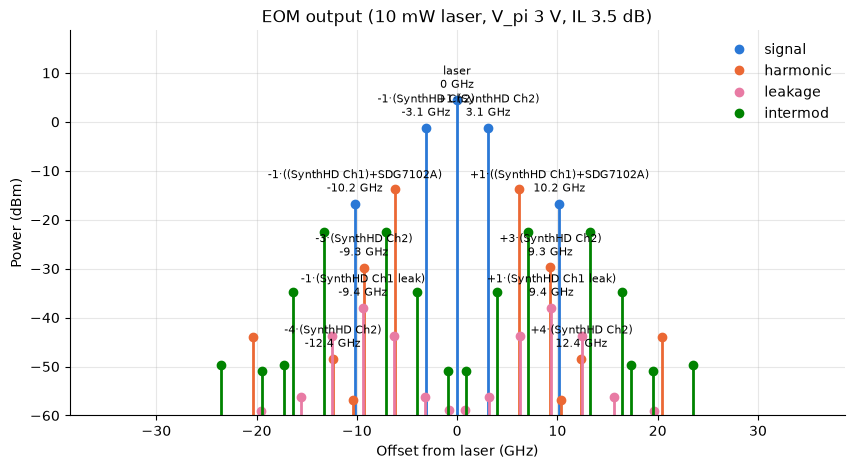

In [ ]:
# Stage 1
f_if = 0.8                      # GHz
awg_q_phase_shift = -90         # °

awg_pow_i = 2                   # dBm
awg_pow_q = 3                   # dBm

windfreak_pump_power = 10       # dBm



# - frequency generation of a 8.4 GHz signal (Windfreak Synth HD V2 - Channel 1)
lo = pll_synthesizer(P_dBm = -1.3, f_GHz = 9.4, preset='SynthHD v2', name='SynthHD Ch1')

# - frequency generation of a 3.1 GHz signal (Windfreak Synth HD V2 - Channel 2)
mw_1 = pll_synthesizer(P_dBm = 10, f_GHz = 3.1, preset='SynthHD v2', name='SynthHD Ch2')

# - frequency generation of a 1.5 - 2 GHz signal (SMBB-B103)
mw_2_i = source(P_dBm=3, f_GHz=f_if, harmonic_dBc=-40 if f_if > 0.5 else -55,
              n_harmonics=5, f_s_GHz=5, name='SDG7102A')

# - frequency generation of a 1.5 - 2 GHz signal (SMBB-B103)
mw_2_q = source(P_dBm=2, f_GHz=f_if, harmonic_dBc=-40 if f_if > 0.5 else -55,phase_deg=awg_q_phase_shift,
              n_harmonics=5, f_s_GHz=5, name='SDG7102A')

plot_stages = {'Stage 1: frequency generation': [lo, mw_1, mw_2_i, mw_2_q]}

# Stage 2 ampllification of SynthHD 8.4 Ghz LO + Attenuator and 
# Amp of LO
lo = amplifier(lo, gain_dB= lambda f : 26.5 if f < 18 else 0, p1db_dBm=25.3, oip3_dBm=33, label='ZVA-183-S+')
lo = attenuator(lo, 6, label='BW-S6W2+')

mw_2_i = filter_from_table(mw_2_i, part='VLF-1200+', label='VLF-1200+ (I)')
mw_2_q = filter_from_table(mw_2_q, part='VLF-1200+', label='VLF-1200+ (Q)')

plot_stages["Stage 2: Aplification of LO, LP on IQ"] = [lo, mw_2_i, mw_2_q]

# Stage 3 - IQ Mixing
# IQ mixer of LO with mw_2_i and mw_2_q
mw_3 = iq_mixer(lo, mw_2_i, mw_2_q, conv_loss_dB=8.5,
                amp_imbalance_dB=0.2, 
                phase_imbalance_deg=4.5,   # or: sideband_suppression_dBc=-30
                lo_rf_isolation_dB=40, 
                if_rf_isolation_dB=25,
                label='ZMIQ-143H-S+')

plot_stages["Stage 3: IQ Mixing"] = [mw_3]

#plot_spectrum(mw_3)

# Stage 4 - IQ Mixing Bandpass of the 9.9-10.4 Ghz signal
mw_3_bp = filter_from_table(mw_3, part='ZVBP-10R5G-S+')      # 9.75-11.25 GHz
mw_3_lp = filter_from_table(mw_3_bp, part='ZLSS-11G-S+')     # DC-11 GHz

# 3.1 GHz line: SynthHD ch2. Its spurs are harmonics (6.2, 9.3 GHz) -> lowpass.
# A highpass is not needed: the SynthHD puts nothing below 3.1 GHz (VCO at
# 6.2 GHz divided by 2, no subharmonic).


mw_1_lp = filter_from_table(mw_1, part='VLF-3800+')         # DC-3.9 GHz

# combiner: diplexer (low loss, filters each input once more).
# Alternative: power_combiner(ch2_lp, rf_lp) -> 3 dB + 0.5 dB loss on both lines.
out = diplexer_combine(mw_1_lp, mw_3_lp, part='ZDSS-5G6G-S+',
                       label='Output (ZDSS-5G6G-S+)')

plot_stages["Stage 4: bandpass + lowpass + diplexer"] = [out]

#axes = plot_stage_rows(plot_stages, dBc=False, floor=-80)
#axes[0][2].get_figure(root=True).savefig("Setup2.png")


opt = eom_laser_output(out, laser_power_mW=10, vpi_V=3.0, insertion_loss_dB=3.5, )
ax = plot_spectrum(opt, floor=-60)
ax.get_figure(root=True).savefig("Setup2_optical.png")

In [21]:
# Setup 2 interactive: laser spectrum after the EOM vs. AWG / pump settings
# Same chain as the "Setup 2" notebook cell (LO 9.4 GHz, SDG7102A I/Q, ZMIQ-143H-S+,
# ZVBP-10R5G-S+, ZLSS-11G-S+, SynthHD ch2 3.1 GHz + VLF-3800+, ZDSS-5G6G-S+ -> EOM),
# wrapped in five sliders. Needs ipywidgets and anywidget (Jupyter / VS Code).

import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display


def setup2_spectra(f_if=0.8, awg_q_phase_shift=-90, awg_pow_i=2, awg_pow_q=3,
                   windfreak_pump_power=10):
    """RF spectrum at the EOM and the optical spectrum after it."""
    harm = -40 if f_if > 0.5 else -55                    # SDG7102A datasheet
    lo = pll_synthesizer(P_dBm=-1.3, f_GHz=9.4, preset='SynthHD v2', name='SynthHD Ch1')
    mw_1 = pll_synthesizer(P_dBm=windfreak_pump_power, f_GHz=3.1, preset='SynthHD v2',
                           name='SynthHD Ch2')
    mw_2_i = source(P_dBm=awg_pow_i, f_GHz=f_if, harmonic_dBc=harm, n_harmonics=5,
                    f_s_GHz=5, name='SDG7102A')
    mw_2_q = source(P_dBm=awg_pow_q, f_GHz=f_if, harmonic_dBc=harm, n_harmonics=5,
                    f_s_GHz=5, phase_deg=awg_q_phase_shift, name='SDG7102A')

    lo = amplifier(lo, gain_dB=lambda f: 26.5 if f < 18 else 0, p1db_dBm=25.3,
                   oip3_dBm=33, label='ZVA-183-S+')
    lo = attenuator(lo, 6, label='BW-S6W2+')
    mw_2_i = filter_from_table(mw_2_i, part='VLF-1200+', label='VLF-1200+ (I)') # LP on I line
    mw_2_q = filter_from_table(mw_2_q, part='VLF-1200+', label='VLF-1200+ (Q)') # LP on Q line

    mw_3 = iq_mixer(lo, mw_2_i, mw_2_q, conv_loss_dB=8.5, amp_imbalance_dB=0.2,
                    phase_imbalance_deg=4.5, lo_rf_isolation_dB=40, if_rf_isolation_dB=25,
                    label='ZMIQ-143H-S+')
    
    
    mw_3_bp = filter_from_table(mw_3, part='ZVBP-10R5G-S+') # BP
    
    mw_3_bp = amplifier(mw_3_bp, gain_dB=lambda f: 26.5 if f < 18 else 0, p1db_dBm=25.3,
                   oip3_dBm=33, label='ZVA-183-S+')
    
    mw_3_lp = filter_from_table(mw_3_bp, part='ZLSS-11G-S+')
    
    mw_3_lp = attenuator(mw_3_lp, 10, label='BW-S10W2+')
    
    
    mw_1_lp = filter_from_table(mw_1, part='VLF-3800+')
    out = diplexer_combine(mw_1_lp, mw_3_lp, part='ZDSS-5G6G-S+', label='Output (ZDSS-5G6G-S+)')
    opt = eom_laser_output(out, laser_power_mW=10, vpi_V=3.0, insertion_loss_dB=3.5)
    return out, opt


def _stems(spectrum, floor):
    """Per tone kind: x, y, hover text, marker sizes for a stem plot (None-separated)."""
    data = {}
    for t in spectrum:
        if t.P_dBm <= floor:
            continue
        x, y, text, size = data.setdefault(t.kind, ([], [], [], []))
        label = f'{t.origin}<br>{t.f_GHz:+.3f} GHz<br>{t.P_dBm:.1f} dBm'
        x += [t.f_GHz, t.f_GHz, None]
        y += [floor, t.P_dBm, None]
        text += [label, label, None]
        size += [0, 7, 0]
    return data


def setup2_widget(floor=-60, vpi_V=3.0):
    """Five sliders -> optical spectrum after the EOM (updates live while dragging)."""
    style = dict(description_width='190px')
    layout = widgets.Layout(width='620px')
    sliders = {
        'f_if': widgets.FloatSlider(value=0.8, min=0.5, max=1.0, step=0.01,
                                    description='awg_f_if (GHz)', readout_format='.2f'),
        'awg_q_phase_shift': widgets.FloatSlider(value=-90, min=-180, max=180, step=1,
                                                 description='Q phase vs. I (°)'),
        'awg_pow_i': widgets.FloatSlider(value=2, min=-20, max=10, step=0.5,
                                         description='AWG I power (dBm)'),
        'awg_pow_q': widgets.FloatSlider(value=3, min=-20, max=10, step=0.5,
                                         description='AWG Q power (dBm)'),
        'windfreak_pump_power': widgets.FloatSlider(value=10, min=-10, max=17, step=0.5,
                                                    description='SynthHD ch2 power (dBm)'),
    }
    for s in sliders.values():
        s.style, s.layout, s.continuous_update = style, layout, True   # ~10 ms per update

    fig = go.FigureWidget()
    for kind, color in KIND_COLORS.items():
        fig.add_scatter(name=kind, mode='lines+markers', line=dict(color=color, width=2),
                        marker=dict(color=color), hovertemplate='%{text}<extra></extra>',
                        x=[], y=[])
    fig.update_layout(height=520, template='plotly_white', hovermode='closest',
                      xaxis_title='Offset from laser (GHz)', yaxis_title='Optical power (dBm)',
                      yaxis_range=[floor, 10], legend=dict(orientation='h', y=1.12))
    info = widgets.HTML()

    def update(_=None):
        values = {k: s.value for k, s in sliders.items()}
        out, opt = setup2_spectra(**values)
        data = _stems(opt, floor)
        sig = sorted((t for t in out if t.kind == 'signal'), key=lambda t: t.f_GHz)
        with fig.batch_update():
            for tr in fig.data:
                x, y, text, size = data.get(tr.name, ([], [], [], []))
                tr.x, tr.y, tr.text, tr.marker.size = x, y, text, size
            fig.layout.title.text = 'Laser after the EOM (10 mW, V_pi 3 V, IL 3.5 dB)'
        line = lambda f: max((t.P_dBm for t in opt if abs(t.f_GHz - f) < 1e-6), default=-np.inf)
        rows = ''.join(
            f'<tr><td>{t.origin}</td><td>{t.f_GHz:.3f} GHz</td><td>{t.P_dBm:.1f} dBm</td>'
            f'<td>β = {modulation_depth(t.P_dBm, vpi_V):.2f}</td>'
            f'<td>±1 sideband: {line(t.f_GHz):.1f} dBm</td></tr>' for t in sig)
        info.value = (f'<table style="font-family:monospace">{rows}'
                      f'<tr><td>laser carrier</td><td></td><td></td><td></td>'
                      f'<td>{line(0.0):.1f} dBm</td></tr></table>')

    for s in sliders.values():
        s.observe(update, names='value')
    update()
    display(widgets.VBox(list(sliders.values()) + [info, fig]))


setup2_widget()